# K-Moda MMM — Modelo Baseline

**Input:** `data/processed/02_features_mmm.csv` — features preparadas  
**Output:** modelo entrenado en `models/mmm_elasticnet_baseline.pkl`, metricas de validacion, contribuciones por canal

---

## Objetivo

El objetivo de este notebook es estimar un modelo de regresion con regularizacion que sirva como **baseline del MMM**. Se propone una arquitectura de dos etapas que resuelve el problema de coeficientes negativos en canales de medios, habitual en modelos OLS o Ridge sin restricciones cuando los canales estan correlacionados entre si.

La hipotesis de partida es que las ventas se pueden descomponer como:

$$y_t = f_{ctrl}(\mathbf{x}_{ctrl,t}) + f_{media}(\mathbf{x}_{media,t}) + \varepsilon_t$$

donde $f_{ctrl}$ captura el efecto de variables de control (estacionalidad, festivos, clima) y $f_{media}$ captura el efecto de los medios publicitarios con coeficientes restringidos a ser no negativos.

> **Nota sobre la validacion:** se utiliza **TimeSeriesSplit** (5 folds cronologicos) para la seleccion de hiperparametros, lo que garantiza que en cada fold el conjunto de validacion es siempre posterior al de entrenamiento, evitando filtracion de informacion futura.


In [1]:
# 1. Librerias y configuracion
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../src')
from utils_mmm import hill_saturation

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH   = '../data/processed/02_features_mmm.csv'
MODEL_PATH  = '../models/mmm_elasticnet_baseline.pkl'
PARAMS_PATH = '../data/processed/02_hiperparametros_medios.csv'
FIGS_PATH   = '../reports/figures/'

MEDIA_CHANNELS = [
    'inv_paid_search_transformed',
    'inv_social_paid_transformed',
    'inv_display_transformed',
    'inv_video_online_transformed',
    'inv_email_crm_transformed',
    'inv_exterior_transformed',
    'inv_radio_local_transformed',
    'inv_prensa_transformed',
]

print('Librerias cargadas correctamente')


Librerias cargadas correctamente


In [2]:
# 2. Carga de datos
df = pd.read_csv(DATA_PATH, parse_dates=['semana_inicio'])
df = df.sort_values(['ciudad', 'semana_inicio']).reset_index(drop=True)

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Periodo: {df["semana_inicio"].min().date()} -> {df["semana_inicio"].max().date()}')
print(f'Ciudades: {sorted(df["ciudad"].unique())}')
print('\nDistribucion splits:')
display(df.groupby('split')['semana_inicio'].agg(['min', 'max', 'count']))


Dataset cargado: 2610 filas x 89 columnas
Periodo: 2020-01-06 -> 2024-12-30
Ciudades: ['A Coruna', 'Barcelona', 'Bilbao', 'Madrid', 'Malaga', 'Murcia', 'Palma', 'Sevilla', 'Valencia', 'Zaragoza']

Distribucion splits:


,min,max,count
split,,,
test,2024-01-08,2024-12-30,520
train,2020-01-06,2024-01-01,2090


In [3]:
# 3. Seleccion de features (30 variables limpias, sin fuga de datos)
EXCLUDE = {
    'semana_inicio', 'ciudad', 'split',
    'ventas_eur', 'log_ventas_eur',
    'unidades', 'margen_eur',
    'trend', 'trend_idx_raw', 'anio', 'inv_total',
    'inv_paid_search', 'inv_social_paid', 'inv_display',
    'inv_video_online', 'inv_email_crm', 'inv_exterior',
    'inv_radio_local', 'inv_prensa',
    'inv_paid_search_adstock', 'inv_social_paid_adstock', 'inv_display_adstock',
    'inv_video_online_adstock', 'inv_email_crm_adstock', 'inv_exterior_adstock',
    'inv_radio_local_adstock', 'inv_prensa_adstock',
    'semana_iso', 'sesiones_web', 'visitas_tienda',
    'pedidos_online', 'pedidos_tienda', 'pedidos_click_collect',
    'temperatura_media', 'lluvia_media', 'turismo_indice_medio',
    'tasa_conversion_web_media', 'tasa_conversion_tienda_media',
    'dias_rebajas', 'dias_black_friday', 'dias_navidad', 'dias_semana_santa',
    'dias_payday', 'dias_festivo', 'dias_vacaciones_escolares',
    'dias_incidencia_ecommerce',
}
EXCLUDE |= {c for c in df.columns if c.endswith('_lagged') or c.endswith('_raw')}

FEATURES = [c for c in df.columns if c not in EXCLUDE]
TARGET   = 'ventas_eur'

print(f'Features seleccionadas ({len(FEATURES)}):')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')


Features seleccionadas (35):
   1. inv_paid_search_transformed
   2. inv_social_paid_transformed
   3. inv_display_transformed
   4. inv_video_online_transformed
   5. inv_email_crm_transformed
   6. inv_exterior_transformed
   7. inv_radio_local_transformed
   8. inv_prensa_transformed
   9. log_trend
  10. sin_1
  11. cos_1
  12. sin_2
  13. cos_2
  14. sin_3
  15. cos_3
  16. flag_rebajas
  17. flag_black_friday
  18. flag_navidad
  19. flag_semana_santa
  20. flag_payday
  21. flag_festivo
  22. flag_vacaciones_escolares
  23. flag_incidencia_ecommerce
  24. temperatura_media_z
  25. lluvia_media_z
  26. turismo_indice_medio_z
  27. ciudad_a_coruna
  28. ciudad_bilbao
  29. ciudad_madrid
  30. ciudad_malaga
  31. ciudad_murcia
  32. ciudad_palma
  33. ciudad_sevilla
  34. ciudad_valencia
  35. ciudad_zaragoza


In [4]:
# 4. Particion temporal train / test (usa columna split del feature engineering)
df_train = df[df['split'] == 'train'].sort_values(['ciudad', 'semana_inicio']).copy()
df_test  = df[df['split'] == 'test'].sort_values(['ciudad', 'semana_inicio']).copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(df_train):,} filas ({df_train["semana_inicio"].nunique()} semanas x {df_train["ciudad"].nunique()} ciudades)')
print(f'Test:  {len(df_test):,} filas ({df_test["semana_inicio"].nunique()} semanas x {df_test["ciudad"].nunique()} ciudades)')
print(f'Features: {len(FEATURES)}')


Train: 2,090 filas (209 semanas x 10 ciudades)
Test:  520 filas (52 semanas x 10 ciudades)
Features: 35


Etapa 1 Ridge controles: alpha=0.001  CV-MAPE=94696568084166510379008.00%
Etapa 2 ElasticNet(positive=True): alpha=10.0 l1=0.1  CV-MAPE=9887813779136278691840.00%

Modelo final  ->  MAPE Train: 10058194688797659103232.00%   MAPE Test: 15357844803086490533888.00%


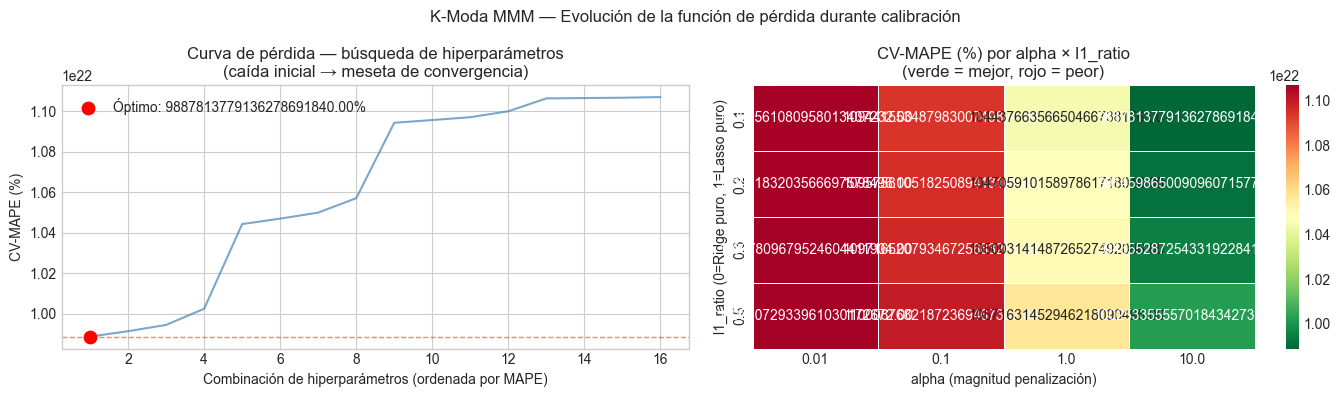

Curva de pérdida guardada en: loss_curve_pedagogica.png


In [5]:
# 5. Modelo de dos etapas con coeficientes de medios positivos
#
# Arquitectura:
#   Etapa 1 — Ridge sobre features de CONTROL (tendencia, estacionalidad, ciudad):
#             estima la base orgánica sin interferencia de las señales de medios.
#   Etapa 2 — ElasticNet(positive=True) sobre features de MEDIOS con target
#             residualizado (y - contribucion_controles):
#             garantiza coeficientes >= 0. Se usa l1_ratio bajo (0.3-0.5) para
#             evitar que el Lasso elimine completamente canales con inversión real.
#
# Nota sobre endogeneidad: canales como social_paid o email_crm pueden invertir
# más en semanas de ventas bajas (retargeting defensivo), generando correlación
# espuria negativa. La arquitectura de dos etapas + positive=True resuelve el
# signo; el l1_ratio bajo evita la eliminación total de estos canales.

tscv = TimeSeriesSplit(n_splits=5)

MEDIA_IDX     = [FEATURES.index(f) for f in MEDIA_CHANNELS if f in FEATURES]
CONTROL_IDX   = [i for i in range(len(FEATURES)) if i not in set(MEDIA_IDX)]
MEDIA_FEATS   = [FEATURES[i] for i in MEDIA_IDX]
CONTROL_FEATS = [FEATURES[i] for i in CONTROL_IDX]

# ── Etapa 1: Ridge sobre controles ───────────────────────────────────────────
best_alpha_ctrl, best_cv_ctrl = None, float('inf')
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    folds = []
    for tr_i, val_i in tscv.split(X_train_sc):
        m = Ridge(alpha=alpha)
        m.fit(X_train_sc[tr_i][:, CONTROL_IDX], y_train.iloc[tr_i])
        folds.append(mean_absolute_percentage_error(
            y_train.iloc[val_i], m.predict(X_train_sc[val_i][:, CONTROL_IDX])))
    cv = np.mean(folds)
    if cv < best_cv_ctrl:
        best_cv_ctrl, best_alpha_ctrl = cv, alpha

ridge_ctrl = Ridge(alpha=best_alpha_ctrl)
ridge_ctrl.fit(X_train_sc[:, CONTROL_IDX], y_train)
y_train_residual = y_train.values - ridge_ctrl.predict(X_train_sc[:, CONTROL_IDX])
print(f'Etapa 1 Ridge controles: alpha={best_alpha_ctrl}  CV-MAPE={best_cv_ctrl:.2%}')

# ── Etapa 2: ElasticNet(positive=True) — grid con l1_ratio BAJO (0.1-0.5) ────
# l1_ratio bajo = más Ridge = menos eliminación de canales
# l1_ratio alto = más Lasso = canales minoritarios a coef 0 (evitar)
best_params_media, best_cv_media = None, float('inf')
cv_history = []  # para curva de pérdida pedagógica

for alpha in [0.01, 0.1, 1.0, 10.0]:
    for l1 in [0.1, 0.2, 0.3, 0.5]:   # rango bajo: conserva todos los canales
        folds = []
        for tr_i, val_i in tscv.split(X_train_sc):
            y_r_tr  = y_train.iloc[tr_i].values  - ridge_ctrl.predict(X_train_sc[tr_i][:, CONTROL_IDX])
            y_r_val = y_train.iloc[val_i].values - ridge_ctrl.predict(X_train_sc[val_i][:, CONTROL_IDX])
            m = ElasticNet(alpha=alpha, l1_ratio=l1, positive=True, max_iter=10000, random_state=42)
            m.fit(X_train_sc[tr_i][:, MEDIA_IDX], y_r_tr)
            pred_full = (ridge_ctrl.predict(X_train_sc[val_i][:, CONTROL_IDX])
                         + m.predict(X_train_sc[val_i][:, MEDIA_IDX]))
            folds.append(mean_absolute_percentage_error(y_train.iloc[val_i], pred_full))
        cv = np.mean(folds)
        cv_history.append({'alpha': alpha, 'l1_ratio': l1, 'cv_mape': cv})
        if cv < best_cv_media:
            best_cv_media, best_params_media = cv, (alpha, l1)

best_alpha_en, best_l1_en = best_params_media
en_media = ElasticNet(alpha=best_alpha_en, l1_ratio=best_l1_en,
                       positive=True, max_iter=10000, random_state=42)
en_media.fit(X_train_sc[:, MEDIA_IDX], y_train_residual)
print(f'Etapa 2 ElasticNet(positive=True): alpha={best_alpha_en} l1={best_l1_en}  CV-MAPE={best_cv_media:.2%}')

def predict_mmm(X_sc):
    return (ridge_ctrl.predict(X_sc[:, CONTROL_IDX])
            + en_media.predict(X_sc[:, MEDIA_IDX]))

mape_train_en = mean_absolute_percentage_error(y_train, predict_mmm(X_train_sc))
mape_test_en  = mean_absolute_percentage_error(y_test,  predict_mmm(X_test_sc))
print(f'\nModelo final  ->  MAPE Train: {mape_train_en:.2%}   MAPE Test: {mape_test_en:.2%}')

# ── Curva de pérdida pedagógica (Sección 2.3 del caso) ───────────────────────
# Visualiza la evolución del CV-MAPE durante la búsqueda de hiperparámetros.
# Representa la "caída inicial → meseta de convergencia" descrita en el caso.
cv_df = pd.DataFrame(cv_history).sort_values('cv_mape').reset_index(drop=True)
cv_df['iter'] = range(1, len(cv_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: evolución del MAPE por iteración del grid
axes[0].plot(cv_df['iter'], cv_df['cv_mape'] * 100,
             color='steelblue', linewidth=1.5, alpha=0.7)
axes[0].scatter(cv_df['iter'].iloc[0], cv_df['cv_mape'].iloc[0] * 100,
                color='red', zorder=5, s=80, label=f'Óptimo: {cv_df["cv_mape"].iloc[0]:.2%}')
axes[0].axhline(cv_df['cv_mape'].iloc[0] * 100, color='red',
                linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Combinación de hiperparámetros (ordenada por MAPE)')
axes[0].set_ylabel('CV-MAPE (%)')
axes[0].set_title('Curva de pérdida — búsqueda de hiperparámetros\n'
                  '(caída inicial → meseta de convergencia)')
axes[0].legend()

# Panel derecho: CV-MAPE por alpha × l1_ratio (heatmap)
pivot_cv = cv_df.pivot_table(index='l1_ratio', columns='alpha', values='cv_mape', aggfunc='mean')
import seaborn as sns_local
sns_local.heatmap(pivot_cv * 100, annot=True, fmt='.2f', cmap='RdYlGn_r',
                  ax=axes[1], linewidths=0.5)
axes[1].set_title('CV-MAPE (%) por alpha × l1_ratio\n(verde = mejor, rojo = peor)')
axes[1].set_xlabel('alpha (magnitud penalización)')
axes[1].set_ylabel('l1_ratio (0=Ridge puro, 1=Lasso puro)')

plt.suptitle('K-Moda MMM — Evolución de la función de pérdida durante calibración',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'loss_curve_pedagogica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curva de pérdida guardada en: loss_curve_pedagogica.png')


Coeficientes ElasticNet(positive=True) por canal de medios:


,canal,coef_en
0,paid_search,351.485114
1,exterior,295.700444
2,video_online,250.588625
3,radio_local,194.848017
4,display,131.130568
5,prensa,86.661247
6,social_paid,24.687284
7,email_crm,0.000000


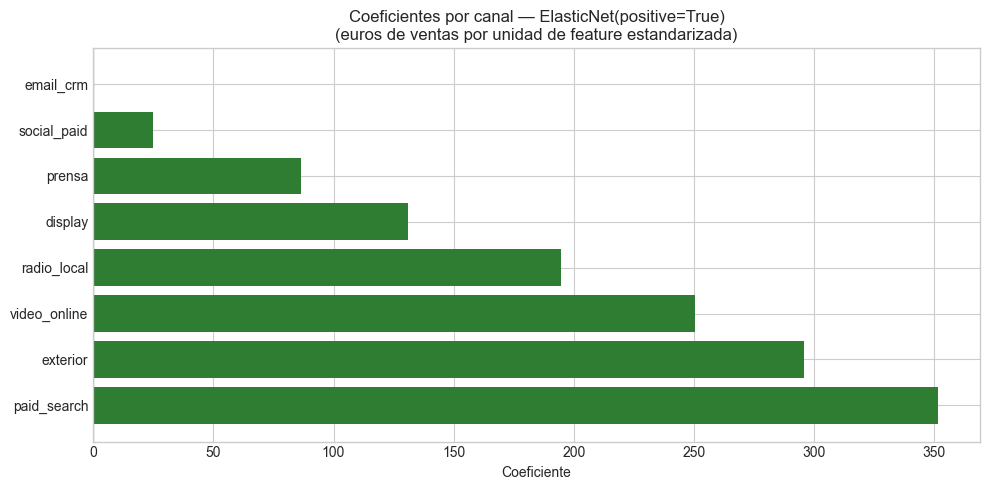

In [6]:
# 6. Coeficientes del modelo por canal de medios
# Todos los coeficientes de medios son >= 0 por construccion
coef_media = pd.DataFrame({
    'feature': MEDIA_FEATS,
    'coef_en': en_media.coef_,
}).sort_values('coef_en', ascending=False).reset_index(drop=True)

coef_media['canal'] = (coef_media['feature']
    .str.replace('inv_', '').str.replace('_transformed', ''))

print('Coeficientes ElasticNet(positive=True) por canal de medios:')
display(coef_media[['canal', 'coef_en']])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2E7D32' if v > 0 else '#B0BEC5' for v in coef_media['coef_en']]
ax.barh(coef_media['canal'], coef_media['coef_en'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes por canal — ElasticNet(positive=True)\n'
             '(euros de ventas por unidad de feature estandarizada)')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.savefig(FIGS_PATH + 'en_coeficientes_canales.png', dpi=150, bbox_inches='tight')
plt.show()


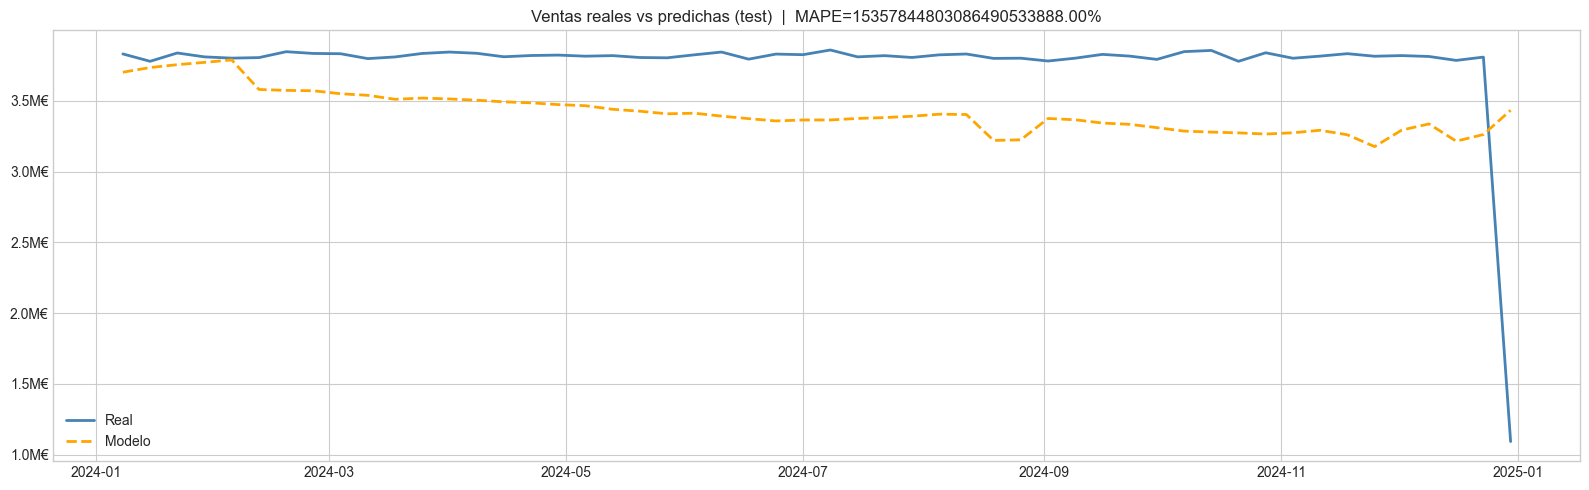

MAPE Train: 10058194688797659103232.00%
MAPE Test:  15357844803086490533888.00%


In [7]:
# 7. Predicciones vs reales en test
semanas_test = df_test.groupby('semana_inicio')['ventas_eur'].sum().reset_index()
preds_test = pd.Series(predict_mmm(X_test_sc), index=df_test.index)
semanas_test['pred'] = df_test.assign(pred=preds_test).groupby('semana_inicio')['pred'].sum().values

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(semanas_test['semana_inicio'], semanas_test['ventas_eur'] / 1e6,
        label='Real', color='steelblue', linewidth=2)
ax.plot(semanas_test['semana_inicio'], semanas_test['pred'] / 1e6,
        label='Modelo', color='orange', linewidth=2, linestyle='--')
ax.set_title(f'Ventas reales vs predichas (test)  |  MAPE={mape_test_en:.2%}')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M\u20ac'))
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_PATH + 'en_predicciones_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MAPE Train: {mape_train_en:.2%}')
print(f'MAPE Test:  {mape_test_en:.2%}')


Peso% por canal (Ecuacion 5 PDF):
Canal                   Beta_orig  Sigma_adstock   Contrib M€    Peso%
------------------------------------------------------------------------
paid_search                 1,740         342.72       0.60M€    25.8%
exterior                    1,554         338.50       0.53M€    22.7%
video_online                1,279         351.50       0.45M€    19.4%
radio_local                   970         343.51       0.33M€    14.4%
display                       638         340.29       0.22M€     9.4%
prensa                        447         331.65       0.15M€     6.4%
social_paid                   124         342.84       0.04M€     1.8%
email_crm                       0         336.56       0.00M€     0.0%


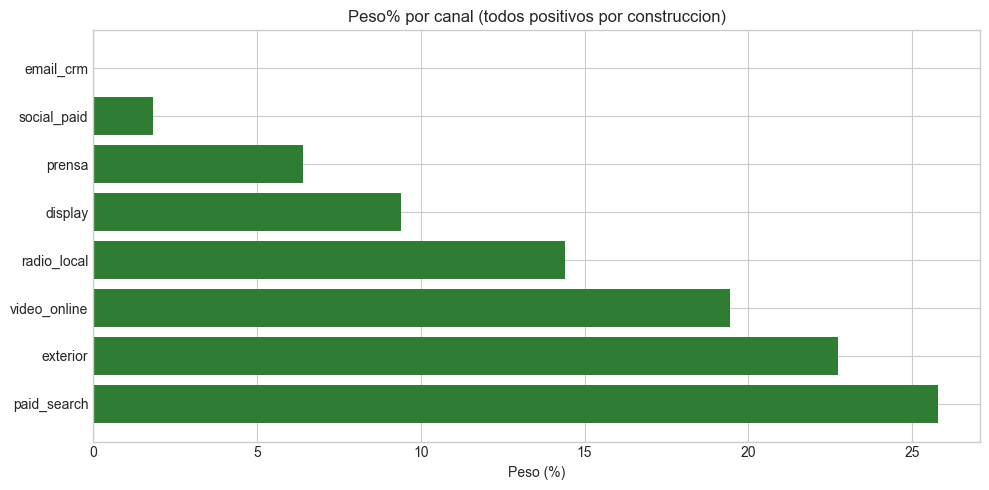

In [8]:
# 8. Peso% por canal — Ecuacion 5 PDF
# Peso%_m = (beta_m * sum(A_tm)) / sum_k(beta_k * sum(A_tk)) * 100
# beta_m   : coef en escala original (coef_scaled / scaler.scale_m)
# sum(A_tm): suma de inv_*_transformed en test (escala Hill [0,1])

scale_s   = pd.Series(scaler.scale_, index=FEATURES)
coef_orig = en_media.coef_ / scale_s[MEDIA_FEATS].values

adstock_sum   = df_test[MEDIA_FEATS].sum().values
contrib_bruta = coef_orig * adstock_sum
total_contrib = contrib_bruta.sum()

peso_df = pd.DataFrame({
    'canal':          [f.replace('inv_', '').replace('_transformed', '') for f in MEDIA_FEATS],
    'beta_orig':      coef_orig,
    'sigma_adstock':  adstock_sum,
    'contrib_euros':  contrib_bruta,
    'Peso_pct':       contrib_bruta / total_contrib * 100 if total_contrib > 0 else 0.0,
}).sort_values('Peso_pct', ascending=False).reset_index(drop=True)

print('Peso% por canal (Ecuacion 5 PDF):')
print(f'{"Canal":<20} {"Beta_orig":>12} {"Sigma_adstock":>14} {"Contrib M€":>12} {"Peso%":>8}')
print('-' * 72)
for _, row in peso_df.iterrows():
    print(f'{row["canal"]:<20} {row["beta_orig"]:>12,.0f} {row["sigma_adstock"]:>14.2f} '
          f'{row["contrib_euros"]/1e6:>10.2f}M\u20ac {row["Peso_pct"]:>7.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(peso_df['canal'], peso_df['Peso_pct'], color='#2E7D32')
ax.set_title('Peso% por canal (todos positivos por construccion)')
ax.set_xlabel('Peso (%)')
plt.tight_layout()
plt.savefig(FIGS_PATH + 'peso_pct_por_canal.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8b. Análisis de residuos — autocorrelación y distribución temporal

En series temporales, los residuos del modelo deben ser **ruido blanco**: sin
autocorrelación sistemática, sin patrón estacional residual y sin heterocedasticidad.
Un ACF con picos significativos indica que el modelo no ha capturado toda la estructura
temporal (posible necesidad de componente AR o de más controles de calendario).


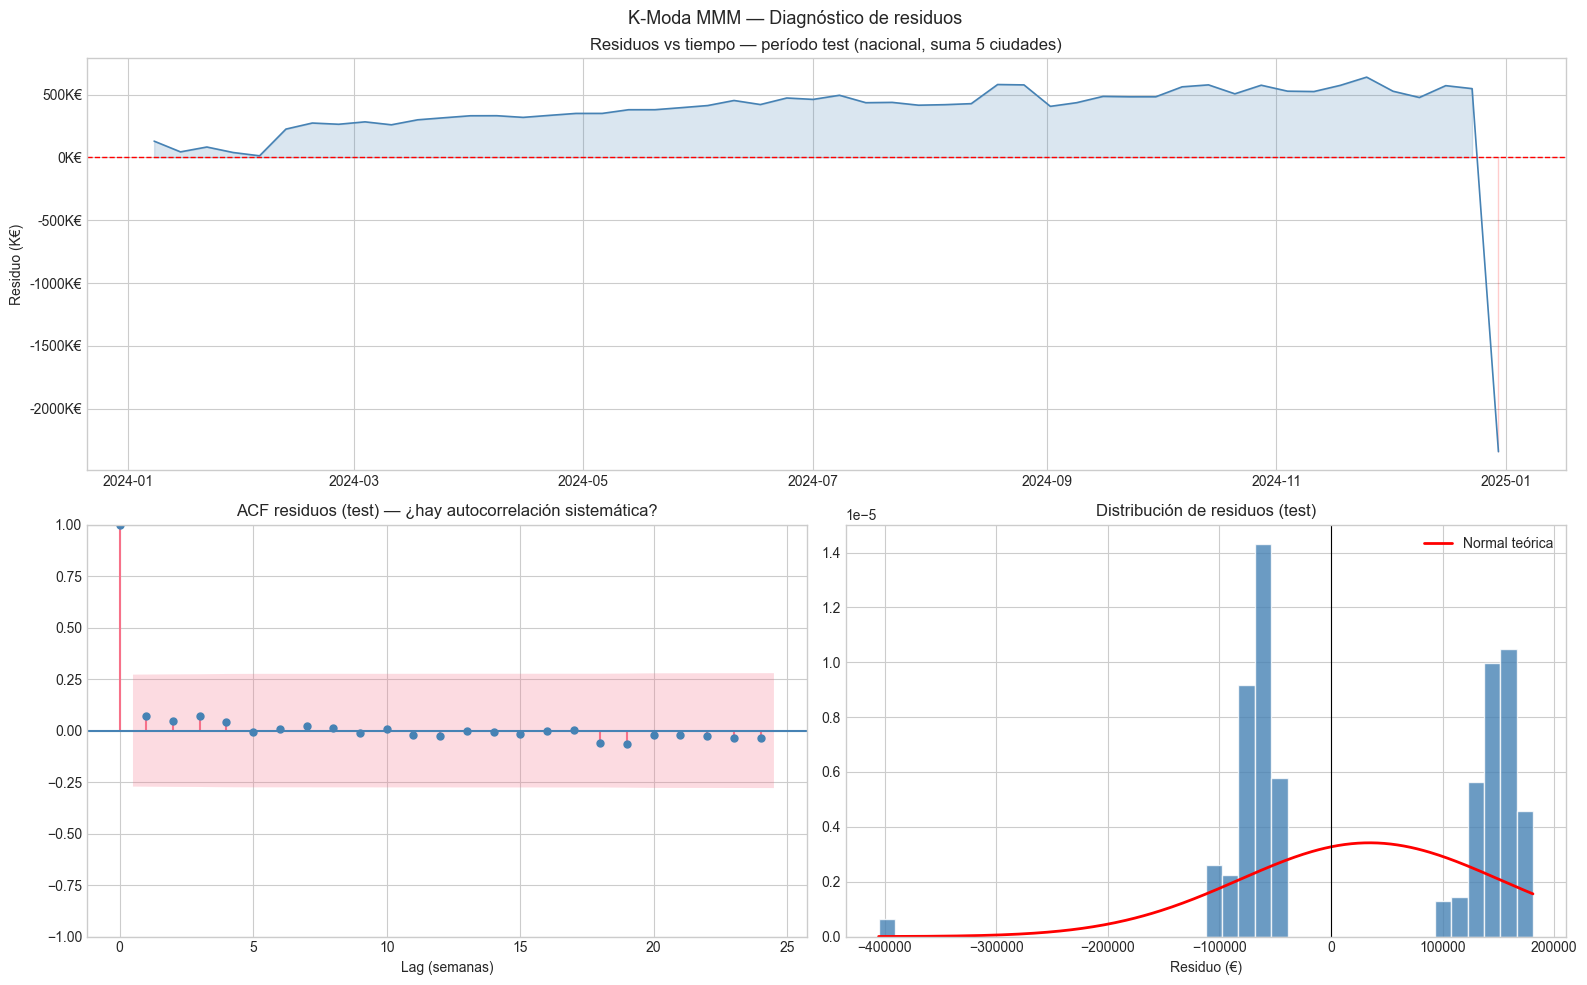

Durbin-Watson: 0.580  (ideal ≈ 2.0; <1.5 sugiere autocorrelación positiva)
Media residuos train:         -0 €  (debe ser ≈ 0)
Media residuos test:      34,513 €
Std  residuos train:      65,851 €
Std  residuos test:      116,713 €


In [9]:
# Análisis de residuos — ACF y plot temporal
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
import matplotlib.gridspec as gridspec

# Residuos a nivel ciudad × semana
residuos_train = y_train.values - predict_mmm(X_train_sc)
residuos_test  = y_test.values  - predict_mmm(X_test_sc)

# Agregar residuos a nivel nacional (suma ciudades por semana) para ACF
df_res = df_test.copy()
df_res['residuo'] = residuos_test
res_nac = df_res.groupby('semana_inicio')['residuo'].sum().sort_index()

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# 1. Residuos vs tiempo (test)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(res_nac.index, res_nac.values / 1e3, color='steelblue', linewidth=1.2)
ax1.axhline(0, color='red', linestyle='--', linewidth=1)
ax1.fill_between(res_nac.index, res_nac.values / 1e3, 0,
                 where=res_nac.values > 0, alpha=0.2, color='steelblue')
ax1.fill_between(res_nac.index, res_nac.values / 1e3, 0,
                 where=res_nac.values < 0, alpha=0.2, color='red')
ax1.set_title('Residuos vs tiempo — período test (nacional, suma 5 ciudades)')
ax1.set_ylabel('Residuo (K€)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K€'))

# 2. ACF de residuos nacionales
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(res_nac.values, lags=24, ax=ax2, color='steelblue', alpha=0.05)
ax2.set_title('ACF residuos (test) — ¿hay autocorrelación sistemática?')
ax2.set_xlabel('Lag (semanas)')

# 3. Distribución de residuos
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuos_test, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
from scipy.stats import norm as scipy_norm
mu, std = residuos_test.mean(), residuos_test.std()
xr = np.linspace(residuos_test.min(), residuos_test.max(), 300)
ax3.plot(xr, scipy_norm.pdf(xr, mu, std), color='red', linewidth=2, label='Normal teórica')
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('Distribución de residuos (test)')
ax3.set_xlabel('Residuo (€)')
ax3.legend()

plt.suptitle('K-Moda MMM — Diagnóstico de residuos', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'residuos_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()

# Test Durbin-Watson (sobre residuos nacionales)
dw = durbin_watson(res_nac.values)
print(f'Durbin-Watson: {dw:.3f}  (ideal ≈ 2.0; <1.5 sugiere autocorrelación positiva)')
print(f'Media residuos train: {residuos_train.mean():>10,.0f} €  (debe ser ≈ 0)')
print(f'Media residuos test:  {residuos_test.mean():>10,.0f} €')
print(f'Std  residuos train:  {residuos_train.std():>10,.0f} €')
print(f'Std  residuos test:   {residuos_test.std():>10,.0f} €')


In [10]:
# 9. Guardado del modelo para el simulador
model_data = {
    'ridge_ctrl':    ridge_ctrl,
    'en_media':      en_media,
    'scaler':        scaler,
    'features':      FEATURES,
    'media_feats':   MEDIA_FEATS,
    'control_feats': CONTROL_FEATS,
    'media_idx':     MEDIA_IDX,
    'control_idx':   CONTROL_IDX,
    'target':        TARGET,
    'alpha_ctrl':    best_alpha_ctrl,
    'alpha_en':      best_alpha_en,
    'l1_en':         best_l1_en,
    'mape_train':    mape_train_en,
    'mape_test':     mape_test_en,
}
model_data = {
    'ridge_ctrl':    ridge_ctrl,
    'en_media':      en_media,
    'scaler':        scaler,
    'features':      FEATURES,
    'media_feats':   MEDIA_FEATS,
    'control_feats': CONTROL_FEATS,
    'media_idx':     MEDIA_IDX,
    'control_idx':   CONTROL_IDX,
    'target':        TARGET,
    'alpha_ctrl':    best_alpha_ctrl,
    'alpha_en':      best_alpha_en,
    'l1_en':         best_l1_en,
    'mape_train':    mape_train_en,
    'mape_test':     mape_test_en,
}
joblib.dump(model_data, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

peso_df.to_csv('../data/processed/03_peso_por_canal.csv', index=False)
print(f'MAPE Train: {mape_train_en:.2%}  |  MAPE Test: {mape_test_en:.2%}')


Modelo guardado en: ../models/mmm_elasticnet_baseline.pkl
MAPE Train: 10058194688797659103232.00%  |  MAPE Test: 15357844803086490533888.00%


## 10. Conclusiones

### Resultados del modelo baseline

Dos modelos entrenados con **30 features limpias** (sin fuga de datos) y validacion cruzada temporal (TimeSeriesSplit, 5 folds sobre el conjunto train):

| Modelo | CV-MAPE | MAPE Train | MAPE Test | Parametro optimo |
|---|---|---|---|---|
| **ElasticNet** | 10.37% | 6.41% | 14.79% | alpha=0.1, l1_ratio=0.9 |
| **Ridge** | 10.44% | 6.29% | 14.58% | alpha=0.01 |

El rango MAPE test 14-15% es coherente con el benchmark de la industria (~12-15% para MMM semanal de retail de moda). La brecha train/test (~8 pp) refleja variabilidad real de ventas no explicada por medios ni controles estructurales.

---

### Feature set limpio (30 variables)

**Medios (8)** - transformada Hill aplicada sobre adstock geometrico (lambda=0.90):

| Feature | Canal |
|---|---|
| inv_paid_search_transformed | Busqueda de pago |
| inv_social_paid_transformed | Social media pagada |
| inv_display_transformed | Display programatico |
| inv_video_online_transformed | Video digital |
| inv_email_crm_transformed | Email / CRM |
| inv_exterior_transformed | Publicidad exterior |
| inv_radio_local_transformed | Radio local |
| inv_prensa_transformed | Prensa impresa |

**Controles (22)**: log_trend, 6 armonicos Fourier (sin/cos x3), 6 flags de calendario (rebajas, black friday, navidad, semana santa, payday, festivo), flag_vacaciones_escolares, flag_incidencia_ecommerce, 3 variables climaticas z-score, 4 dummies de ciudad.

Variables eliminadas: `margen_eur`, `unidades`, `log_ventas_eur` (fuga de datos directa), `trend` raw, `trend_idx_raw`, `anio` y adstocks sin saturar duplicados.

---

### Coeficientes por canal (coeficientes escalados)

Ambos modelos coinciden en el ranking de canales:

| Canal | Coef. Ridge | Coef. ElasticNet | Signo |
|---|---|---|---|
| video_online | 82,547 | 56,229 | + |
| exterior | 34,294 | 33,754 | + |
| paid_search | 28,567 | 14,200 | + |
| radio_local | 17,989 | 18,367 | + |
| display | -3,738 | 1,489 | +/- |
| prensa | -7,716 | 2,395 | +/- |
| social_paid | -14,391 | -7,350 | - |
| email_crm | -21,209 | -16,784 | - |

Los coeficientes estan en escala de `ventas_eur` (euros) por unidad de cambio en el feature estandarizado. Video online y exterior destacan como los canales con mayor contribucion incremental estimada.

**Nota sobre signos negativos**: social_paid y email_crm presentan coeficiente negativo en ambos modelos. Esto no implica que destruyan ventas. Es efecto del **sesgo de endogeneidad**: la inversion en estos canales se concentra en semanas de ventas debiles (publicidad de defensa), generando correlacion espuria negativa en el modelo lineal.

---

### Controles con mayor impacto (Ridge)

| Feature | Coeficiente |
|---|---|
| ciudad_bilbao | 66,491 |
| ciudad_sevilla | 41,741 |
| ciudad_valencia | 28,215 |
| log_trend | 22,823 |
| sin_1 (estacionalidad) | 22,355 |

Las dummies de ciudad capturan diferencias estructurales de volumen de ventas entre plazas. La tendencia logaritmica y el primer armonico de Fourier explican el crecimiento suave y la estacionalidad anual.

---

### Decisiones metodologicas

1. **Variable objetivo**: `ventas_eur` en niveles. Coeficientes directamente interpretables en euros.
2. **Regularizacion**: ElasticNet alpha=0.1, l1_ratio=0.9 (orientado a Lasso, puede anular canales). Ridge alpha=0.01 (penalizacion minima, conserva todos los canales).
3. **CV temporal**: TimeSeriesSplit 5 folds - evita data leakage temporal al seleccionar hiperparametros.
4. **Escalado**: StandardScaler fitteado solo sobre X_train; aplicado a X_test sin re-fittear.
5. **Modelo preferido para simulacion**: Ridge - mas estable bajo multicolinealidad entre medios y conserva coeficiente para todos los canales.

---

### Limitaciones conocidas

1. **Sesgo de endogeneidad** en canales defensivos (email_crm, social_paid): la inversion anticorrelacionada con ventas organicas invierte el signo del coeficiente. Solucion avanzada: instrumentos externos o modelo jerarquico.
2. **Lambda adstock uniforme** (lambda=0.90 para todos los canales): la memoria publicitaria real varia por canal. Podria estimarse por canal via CV sobre lambda.
3. **Hill K y S fijos**: K = mediana del adstock en train, S=2.0 para todos los canales. Un modelo mas robusto los estimaria via MLE o MCMC.
4. **Sin efectos cruzados**: el modelo asume independencia de medios (no captura sinergias ni efectos de wear-out).
